# Cornell EMCS Walkthrough

This notebook shows the Cornell EMCS electricity workflow in the two modes we care about:

- `rolling`: walk-forward scoring using past data only
- `all`: full-history inspection

The detector itself is the same in both cases. What changes is how the demo feeds historical data into it.

In [1]:
from __future__ import annotations

import contextlib
import io
import sys
from pathlib import Path

REPO_ROOT = Path.cwd().resolve().parent if Path.cwd().name == "notebooks" else Path.cwd().resolve()
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

with contextlib.redirect_stderr(io.StringIO()):
    import matplotlib.pyplot as plt
    import pandas as pd

from benchmarks.cornell_emcs_electricity_demo import DEFAULT_CSV_PATH, run_emcs_demo

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_columns", 20)
pd.set_option("display.width", 140)

In [2]:
csv_path = DEFAULT_CSV_PATH
output_dir = REPO_ROOT / "out" / "cornell_notebook"

rolling = run_emcs_demo(
    csv_path,
    output_dir=str(output_dir),
    mode="rolling",
    initial_train_frac=0.6,
)
full = run_emcs_demo(
    csv_path,
    output_dir=str(output_dir),
    mode="all",
    initial_train_frac=0.6,
)

summary = pd.DataFrame(
    [
        {
            "mode": "rolling",
            "cadence": rolling["cadence"],
            "fit_rows": len(rolling["fit_df"]),
            "scored_rows": len(rolling["scored"]),
            "events": len(rolling["events_df"]),
            "score_start": rolling["scored"]["timestamp"].min(),
            "score_end": rolling["scored"]["timestamp"].max(),
        },
        {
            "mode": "all",
            "cadence": full["cadence"],
            "fit_rows": len(full["fit_df"]),
            "scored_rows": len(full["scored"]),
            "events": len(full["events_df"]),
            "score_start": full["scored"]["timestamp"].min(),
            "score_end": full["scored"]["timestamp"].max(),
        },
    ]
)
summary

,mode,cadence,fit_rows,scored_rows,events,score_start,score_end
0,rolling,daily,438,292,4,2025-08-14 20:00:00,2026-06-01 20:00:00
1,all,daily,730,730,5,2024-06-02 20:00:00,2026-06-01 20:00:00


## Rolling Events

These are the events from the history-only walk-forward run. This is the main table to trust when you want to know what the detector would have surfaced using only past data.

In [3]:
rolling["events_df"]

,entity_id,start_time,end_time,duration,direction,max_abs_score,mean_abs_score,observed_mean,expected_mean,residual_mean,reason
2,AliceCookHouse.Elec.PowerScout18/kWsystem,2025-12-19 19:00:00,2026-01-09 19:00:00,22 days,low,5.799360,4.713745,44.038889,80.975000,-36.936111,Electricity usage was persistently low for 22 ...
0,AliceCookHouse.Elec.PowerScout18/kWsystem,2025-08-22 20:00:00,2025-08-25 20:00:00,4 days,high,4.691852,4.259942,105.000000,69.000000,36.000000,Electricity usage was persistently high for 4 ...
1,AliceCookHouse.Elec.PowerScout18/kWsystem,2025-10-10 20:00:00,2025-10-13 20:00:00,4 days,low,4.615946,4.376411,64.150000,98.300000,-34.150000,Electricity usage was persistently low for 4 d...
3,AliceCookHouse.Elec.PowerScout18/kWsystem,2026-05-22 20:00:00,2026-05-27 20:00:00,6 days,low,4.190018,3.989689,49.933333,79.883333,-29.950000,Electricity usage was persistently low for 6 d...


## Rolling Score Plot

The blue line is observed usage, the orange line is expected usage, and the shaded bands are detected rolling events.

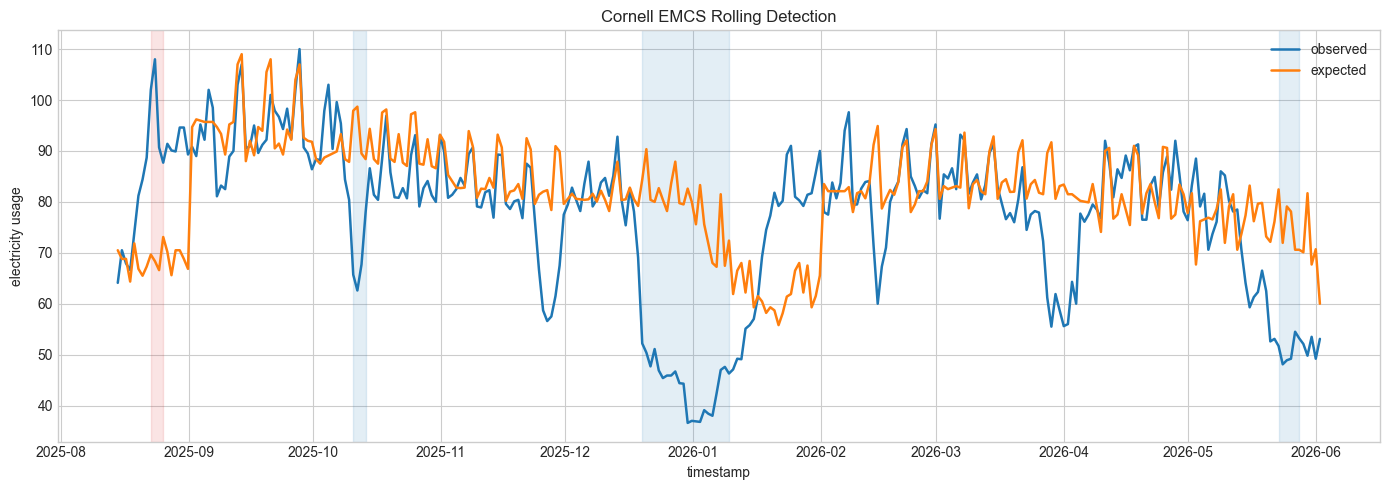

In [4]:
rolling_scored = rolling["scored"].copy()
rolling_events = rolling["events_df"].copy()

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(rolling_scored["timestamp"], rolling_scored["value"], label="observed", linewidth=1.8)
ax.plot(rolling_scored["timestamp"], rolling_scored["expected"], label="expected", linewidth=1.8)

for _, row in rolling_events.iterrows():
    color = "tab:red" if row["direction"] == "high" else "tab:blue"
    ax.axvspan(row["start_time"], row["end_time"], color=color, alpha=0.12)

ax.set_title("Cornell EMCS Rolling Detection")
ax.set_xlabel("timestamp")
ax.set_ylabel("electricity usage")
ax.legend()
plt.tight_layout()
plt.show()

## Compare Against Full-History Inspection

`all` mode is useful for exploring the entire series, but it is not leakage-safe. The table below makes it easy to see which events only appear when the model is allowed to score the same history it fit on.

In [5]:
full_events = full["events_df"].copy()
full_events["source_mode"] = "all"
rolling_events = rolling["events_df"].copy()
rolling_events["source_mode"] = "rolling"

pd.concat([rolling_events, full_events], ignore_index=True).sort_values(
    ["start_time", "source_mode"]
).reset_index(drop=True)

,entity_id,start_time,end_time,duration,direction,max_abs_score,mean_abs_score,observed_mean,expected_mean,residual_mean,reason,source_mode
0,AliceCookHouse.Elec.PowerScout18/kWsystem,2024-11-27 19:00:00,2024-12-01 19:00:00,5 days,low,4.135610,3.977279,51.400000,82.800000,-31.400000,Electricity usage was persistently low for 5 d...,all
1,AliceCookHouse.Elec.PowerScout18/kWsystem,2024-12-23 19:00:00,2025-01-03 19:00:00,12 days,low,6.624576,5.964018,31.820000,78.905000,-47.085000,Electricity usage was persistently low for 12 ...,all
2,AliceCookHouse.Elec.PowerScout18/kWsystem,2025-03-31 20:00:00,2025-04-06 20:00:00,7 days,low,4.965265,4.423139,47.660000,82.580000,-34.920000,Electricity usage was persistently low for 7 d...,all
3,AliceCookHouse.Elec.PowerScout18/kWsystem,2025-08-22 20:00:00,2025-08-25 20:00:00,4 days,high,4.414273,4.113444,105.000000,72.525000,32.475000,Electricity usage was persistently high for 4 ...,all
4,AliceCookHouse.Elec.PowerScout18/kWsystem,2025-08-22 20:00:00,2025-08-25 20:00:00,4 days,high,4.691852,4.259942,105.000000,69.000000,36.000000,Electricity usage was persistently high for 4 ...,rolling
5,AliceCookHouse.Elec.PowerScout18/kWsystem,2025-10-10 20:00:00,2025-10-13 20:00:00,4 days,low,4.615946,4.376411,64.150000,98.300000,-34.150000,Electricity usage was persistently low for 4 d...,rolling
6,AliceCookHouse.Elec.PowerScout18/kWsystem,2025-12-19 19:00:00,2026-01-09 19:00:00,22 days,low,5.799360,4.713745,44.038889,80.975000,-36.936111,Electricity usage was persistently low for 22 ...,rolling
7,AliceCookHouse.Elec.PowerScout18/kWsystem,2025-12-21 19:00:00,2026-01-09 19:00:00,20 days,low,5.763254,4.318483,42.312500,76.406250,-34.093750,Electricity usage was persistently low for 20 ...,all
8,AliceCookHouse.Elec.PowerScout18/kWsystem,2026-05-22 20:00:00,2026-05-27 20:00:00,6 days,low,4.190018,3.989689,49.933333,79.883333,-29.950000,Electricity usage was persistently low for 6 d...,rolling
